In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

def f(t,X):
    x, y, z = X
    
    return np.array([
         10*(y-x),
         28*x - x*z - y,
         x*y - 8*z/3
    ])

In [2]:
X0 = np.array([5,5,5])
EPSILON = 1e-9
X02 = np.array([5,5,5+EPSILON])
N = 10000
t_eval = np.linspace(0, 40, N)

sol1 = scipy.integrate.solve_ivp(f, (0, 40), X0, t_eval=t_eval, rtol=1e-10, atol=1e-12)
sol2 = scipy.integrate.solve_ivp(f, (0, 40), X02, t_eval=t_eval, rtol=1e-10, atol=1e-12)

print(sol1.y[:,-1])
print(sol2.y[:,-1])

[ 2.99621177  0.24713538 25.48885313]
[-3.21387404 -2.91535066 21.4675152 ]


<Figure size 640x480 with 0 Axes>

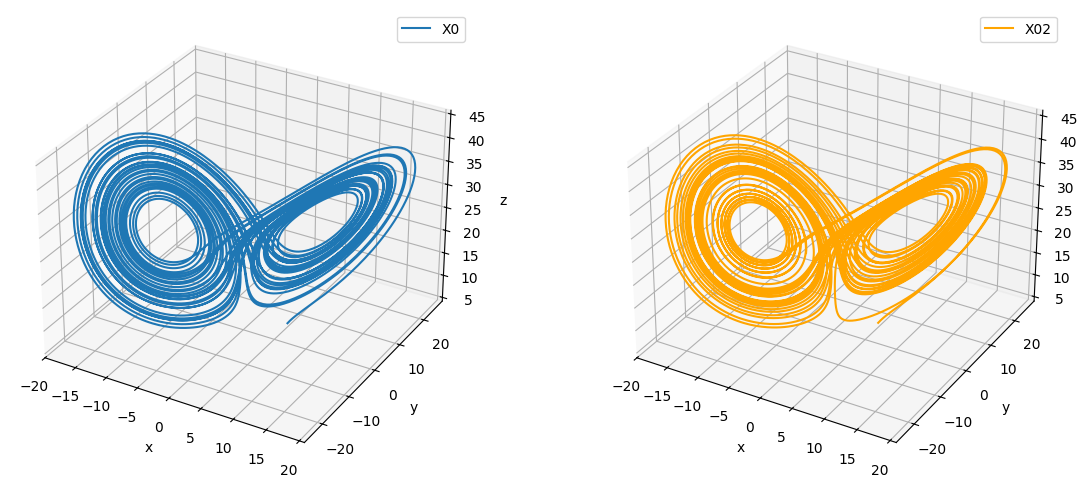

In [3]:
fig = plt.figure()
fig, ax = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})
ax[0].plot(sol1.y[0], sol1.y[1], sol1.y[2], label="X0")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_zlabel("z")
ax[0].legend()
ax[1].plot(sol2.y[0], sol2.y[1], sol2.y[2], color="orange", label="X02")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_zlabel("z")
ax[1].legend()
plt.show()


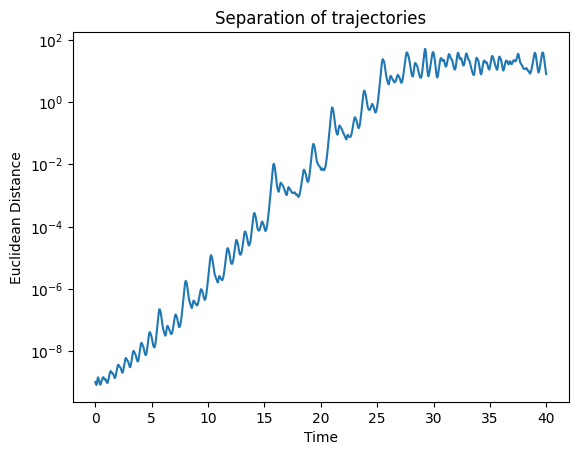

In [10]:
euc_dist = np.sqrt(np.sum((sol1.y - sol2.y)**2, axis=0))
plt.plot(sol1.t, euc_dist)  
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Euclidean Distance")
plt.title("Separation of trajectories")
plt.show()


In [ ]:
seed = 42
np.random.seed(seed)
x = np.random.uniform(-15,15, size=100)
y = np.random.uniform(-15,15, size=100)
z = np.random.uniform(0,30, size=100)

X0_base = np.array([x,y,z])
X0_alt = np.zeros_like(X0_base)

for i in range(X0_base.shape[1]):
    random_index = np.random.randint(0, 3)
    epsilon_vector = np.zeros(3)    
    epsilon_vector[random_index] = EPSILON
    X0_alt[:,i] = X0_base[:,i] + epsilon_vector

base_solutions = []
alt_solutions = []
for i in range(X0_base.shape[1]):
    sol_base = scipy.integrate.solve_ivp(f, (0, 40), X0_base[:,i], t_eval=t_eval, rtol=1e-10, atol=1e-12)
    sol_alt = scipy.integrate.solve_ivp(f, (0, 40), X0_alt[:,i], t_eval=t_eval, rtol=1e-10, atol=1e-12)
    base_solutions.append(sol_base)
    alt_solutions.append(sol_alt)
    

Estimated Lyapunov exponent: 0.9072


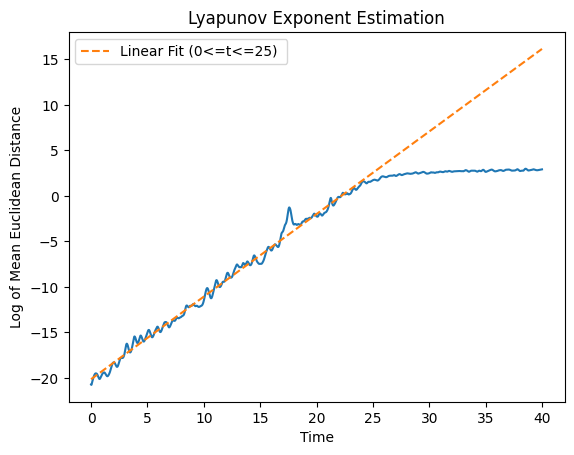

Estimated Lyapunov time: 1.1023


In [40]:
distances = []
for sol_base, sol_alt in zip(base_solutions, alt_solutions):
    dist = np.sqrt(np.sum((sol_base.y - sol_alt.y)**2, axis=0))
    distances.append(dist)
mean_distance = np.mean(distances, axis=0)
log_mean_distance = np.log(mean_distance)
t_region = t_eval[t_eval <= 25]
log_mean_distance_region = log_mean_distance[t_eval <= 25]
model = np.polyfit(t_region, log_mean_distance_region, 1)
print(f"Estimated Lyapunov exponent: {model[0]:.4f}")
fit_line = np.poly1d(model)(t_eval)
plt.plot(t_eval, log_mean_distance)
plt.plot(t_eval, fit_line, '--', label="Linear Fit (0<=t<=25) ")
plt.xlabel("Time")
plt.ylabel("Log of Mean Euclidean Distance")
plt.title("Lyapunov Exponent Estimation")
plt.legend()
plt.show()
lambda_estimate = model[0]
lypunov_time = 1 / lambda_estimate
print(f"Estimated Lyapunov time: {lypunov_time:.4f}")



TASK 2

In [77]:
seed = 40
np.random.seed(seed)
x = np.random.uniform(-15,15, size=100)
y = np.random.uniform(-15,15, size=100)
z = np.random.uniform(0,30, size=100)
t_eval = np.linspace(0, 4, 400)
X0_base_nn = np.array([x,y,z])

base_solutions_nn = []
for i in range(X0_base_nn.shape[1]):
    sol_base_nn = scipy.integrate.solve_ivp(f, (0, 4), X0_base_nn[:,i], t_eval=t_eval, rtol=1e-10, atol=1e-12)
    base_solutions_nn.append(sol_base_nn)
    

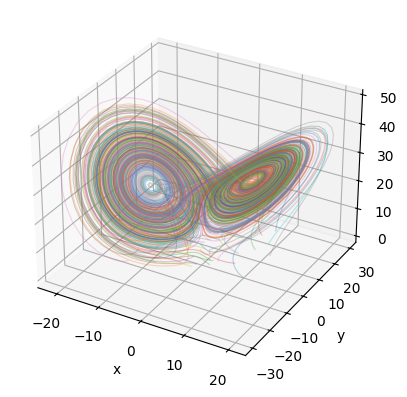

In [78]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for sol in base_solutions_nn[0:100]:
    ax.plot(sol.y[0], sol.y[1], sol.y[2], alpha=0.3, linewidth=0.8)
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_xlabel("x")
plt.show()

train_solutions = base_solutions_nn[:80]
test_solutions = base_solutions_nn[80:]

In [79]:
input = np.array([sol.y.T[ :-1,:] for sol in train_solutions])
labels = np.array([sol.y.T[ 1:,:] for sol in train_solutions])

inputs_test = np.array([sol.y.T[ :-1,:] for sol in test_solutions])
labels_test = np.array([sol.y.T[ 1:,:] for sol in test_solutions])



input_reshaped = input.reshape(-1, 3)
labels_reshaped = labels.reshape(-1, 3)
inputs_test_reshaped = inputs_test.reshape(-1, 3)
labels_test_reshaped = labels_test.reshape(-1, 3)
input_reshaped.shape, labels_reshaped.shape, inputs_test_reshaped.shape, labels_test_reshaped.shape

((31920, 3), (31920, 3), (7980, 3), (7980, 3))

In [76]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
input_scaled = scaler.fit_transform(input_reshaped)
labels_scaled = scaler.transform(labels_reshaped)
inputs_test_scaled = scaler.transform(inputs_test_reshaped)
labels_test_scaled = scaler.transform(labels_test_reshaped)
